# Sistema Fuzzy Mamdani para Controle de Ventilação em Ambientes Fechados

Este notebook implementa um sistema fuzzy Mamdani para auxiliar no controle da ventilação de ambientes fechados, promovendo conforto térmico e eficiência energética. O sistema utiliza como entradas: temperatura interna (°C), umidade relativa (%) e número de pessoas.

## 1. Definição dos Universos de Discurso e Funções de Pertinência

Cada variável de entrada e saída é particionada em três conjuntos fuzzy com funções de pertinência triangulares.

In [123]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Função para obter os parâmetros (a, b, c) das funções triangulares dividindo o intervalo em partes iguais
def parametros_triangulares(univ, n_conjuntos):
    """
    Retorna uma lista de tuplas (a, b, c) para cada função triangular,
    onde o final de um conjunto coincide com o início do próximo:
    (a, b, c), (b, c, d), (c, d, e), etc.
    """
    xmin, xmax = univ[0], univ[-1]
    # Gera pontos igualmente espaçados para os vértices dos triângulos
    pontos = np.linspace(xmin, xmax, n_conjuntos + 2)
    parametros = []
    for i in range(n_conjuntos):
        a = pontos[i]
        b = pontos[i+1]
        c = pontos[i+2]
        parametros.append((a, b, c))
    return parametros

# Função de pertinência triangular
def trimf(x, a, b, c):
    return np.maximum(np.minimum((x-a)/(b-a+1e-9), (c-x)/(c-b+1e-9)), 0)

# Universos de discurso
temp_univ = np.arange(15, 40, 0.1)
umid_univ = np.arange(20, 90, 0.1)
pess_univ = np.arange(0, 50, 0.1)
vent_univ = np.arange(0, 100, 0.1)

# Parâmetros das funções triangulares para cada variável
param_temp = parametros_triangulares(temp_univ, 3)
param_umid = parametros_triangulares(umid_univ, 3)
param_pess = parametros_triangulares(pess_univ, 3)
param_vent = parametros_triangulares(vent_univ, 3)

# Temperatura
def temp_baixa(x):  return trimf(x, *param_temp[0])
def temp_media(x):  return trimf(x, *param_temp[1])
def temp_alta(x):   return trimf(x, *param_temp[2])

# Umidade
def umid_baixa(x):  return trimf(x, *param_umid[0])
def umid_media(x):  return trimf(x, *param_umid[1])
def umid_alta(x):   return trimf(x, *param_umid[2])

# Pessoas
def pess_poucas(x):   return trimf(x, *param_pess[0])
def pess_moderado(x): return trimf(x, *param_pess[1])
def pess_muitas(x):   return trimf(x, *param_pess[2])

# Ventilação (saída)
def vent_fraca(x):    return trimf(x, *param_vent[0])
def vent_moderada(x): return trimf(x, *param_vent[1])
def vent_forte(x):    return trimf(x, *param_vent[2])

def print_parametros_legiveis(parametros, nome):
    """
    Imprime os parâmetros (a, b, c) de forma legível, removendo np.float64.
    """
    print(f"Parâmetros {nome}:")
    for i, (a, b, c) in enumerate(parametros):
        print(f"  {i+1}: ({float(a):.2f}, {float(b):.2f}, {float(c):.2f})")

print_parametros_legiveis(param_temp, "temperatura")
print_parametros_legiveis(param_umid, "umidade")
print_parametros_legiveis(param_pess, "pessoas")
print_parametros_legiveis(param_vent, "ventilação")

Parâmetros temperatura:
  1: (15.00, 21.22, 27.45)
  2: (21.22, 27.45, 33.67)
  3: (27.45, 33.67, 39.90)
Parâmetros umidade:
  1: (20.00, 37.48, 54.95)
  2: (37.48, 54.95, 72.43)
  3: (54.95, 72.43, 89.90)
Parâmetros pessoas:
  1: (0.00, 12.48, 24.95)
  2: (12.48, 24.95, 37.43)
  3: (24.95, 37.43, 49.90)
Parâmetros ventilação:
  1: (0.00, 24.98, 49.95)
  2: (24.98, 49.95, 74.93)
  3: (49.95, 74.93, 99.90)


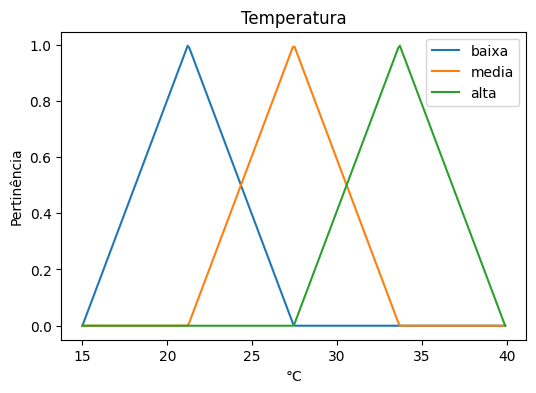

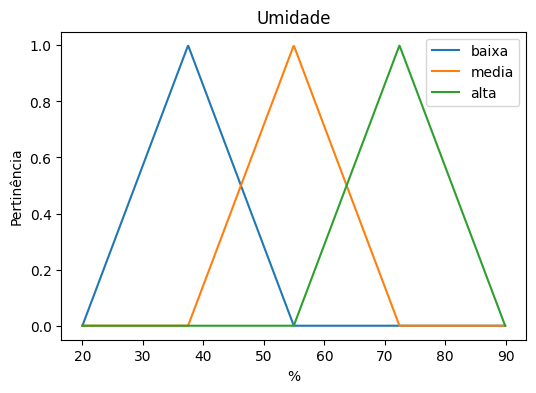

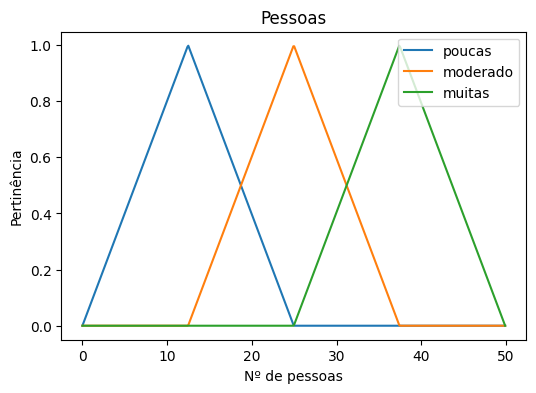

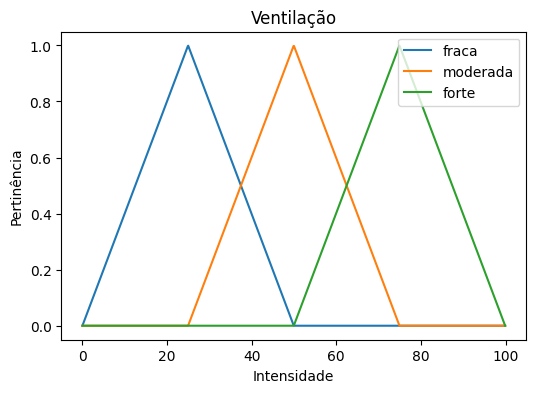

In [124]:
# Visualização das funções de pertinência separadamente e salvando cada gráfico em um arquivo diferente
import matplotlib.pyplot as plt
# Temperatura
plt.figure(figsize=(6,4))
plt.plot(temp_univ, temp_baixa(temp_univ), label='baixa')
plt.plot(temp_univ, temp_media(temp_univ), label='media')
plt.plot(temp_univ, temp_alta(temp_univ), label='alta')
plt.title('Temperatura')
plt.xlabel('°C')
plt.ylabel('Pertinência')
plt.legend()
if not os.path.exists("img"):
    os.makedirs("img")
plt.savefig("img/fp_temp_mamdani2.png")
plt.show()

# Umidade
plt.figure(figsize=(6,4))
plt.plot(umid_univ, umid_baixa(umid_univ), label='baixa')
plt.plot(umid_univ, umid_media(umid_univ), label='media')
plt.plot(umid_univ, umid_alta(umid_univ), label='alta')
plt.title('Umidade')
plt.xlabel('%')
plt.ylabel('Pertinência')
plt.legend()
plt.savefig("img/fp_umid_mamdani2.png")
plt.show()

# Pessoas
plt.figure(figsize=(6,4))
plt.plot(pess_univ, pess_poucas(pess_univ), label='poucas')
plt.plot(pess_univ, pess_moderado(pess_univ), label='moderado')
plt.plot(pess_univ, pess_muitas(pess_univ), label='muitas')
plt.title('Pessoas')
plt.xlabel('Nº de pessoas')
plt.ylabel('Pertinência')
plt.legend()
plt.savefig("img/fp_pessoas_mamdani2.png")
plt.show()

# Ventilação
plt.figure(figsize=(6,4))
plt.plot(vent_univ, vent_fraca(vent_univ), label='fraca')
plt.plot(vent_univ, vent_moderada(vent_univ), label='moderada')
plt.plot(vent_univ, vent_forte(vent_univ), label='forte')
plt.title('Ventilação')
plt.xlabel('Intensidade')
plt.ylabel('Pertinência')
plt.legend()
plt.savefig("img/fp_ventilacao_mamdani2.png")
plt.show()

## 2. Base de Regras Fuzzy

As regras foram construídas com base em conhecimento comum sobre conforto térmico:

In [125]:
def regras_fuzzy(mu_temp, mu_umid, mu_pess, operador='padrao'):
    # Esta função define a base de regras fuzzy para o sistema Mamdani.
    # Ela recebe os graus de pertinência das entradas (temperatura, umidade, pessoas)
    # e retorna uma lista de regras com o firing strength (nível de ativação) de cada uma.
    # O parâmetro 'operador' permite escolher o tipo de agregação lógica (AND/OR).

    regras = []  # Lista para armazenar as regras e seus firing strengths

    # Define os operadores lógicos padrão (min para AND, max para OR)
    min_op = min
    max_op = max

    # Se o operador for 'and_produto', usa o produto ao invés do mínimo para o AND
    if operador == 'and_produto':
        min_op = lambda a, b: a * b

    # Se o operador for 'or_soma', usa a soma limitada a 1 para o OR
    if operador == 'or_soma':
        max_op = lambda a, b, c: min(a + b + c, 1)

    # Cada regra é definida como uma tupla: (nome_saida, firing_strength, identificador)
    # O firing_strength é calculado usando os graus de pertinência das entradas e os operadores lógicos

    # R1: Se temperatura é alta OU umidade é alta OU pessoas são muitas, então ventilação é forte
    regras.append(('forte', max_op(mu_temp['alta'], mu_umid['alta'], mu_pess['muitas']), 'R1'))

    # R2: Se temperatura é média E umidade é média E pessoas são moderadas, então ventilação é moderada
    regras.append(('moderada', min_op(mu_temp['media'], min_op(mu_umid['media'], mu_pess['moderado'])), 'R2'))

    # R3: Se temperatura é baixa E umidade é baixa E poucas pessoas, então ventilação é fraca
    regras.append(('fraca', min_op(mu_temp['baixa'], min_op(mu_umid['baixa'], mu_pess['poucas'])), 'R3'))

    # R4: Se temperatura é alta E umidade é baixa, então ventilação é moderada
    regras.append(('moderada', min_op(mu_temp['alta'], mu_umid['baixa']), 'R4'))

    # R5: Se temperatura é média E pessoas são muitas, então ventilação é forte
    regras.append(('forte', min_op(mu_temp['media'], mu_pess['muitas']), 'R5'))

    # R6: Se umidade é alta E poucas pessoas, então ventilação é moderada
    regras.append(('moderada', min_op(mu_umid['alta'], mu_pess['poucas']), 'R6'))

    # R7: Se temperatura é baixa OU umidade é baixa, então ventilação é fraca
    regras.append(('fraca', max_op(mu_temp['baixa'], mu_umid['baixa'], 0), 'R7'))

    # R8: Se pessoas são moderadas E umidade é média, então ventilação é moderada
    regras.append(('moderada', min_op(mu_pess['moderado'], mu_umid['media']), 'R8'))

    # R9: Se temperatura é média E umidade é alta, então ventilação é forte
    regras.append(('forte', min_op(mu_temp['media'], mu_umid['alta']), 'R9'))

    # Retorna a lista de regras com seus firing strengths
    return regras

## 3. Fuzzificação das Entradas

In [126]:
def fuzzificar(entrada):
    # Esta função realiza a fuzzificação das entradas do sistema fuzzy.
    # Ela recebe um dicionário 'entrada' com os valores das variáveis de entrada:
    # - 'temperatura': valor numérico da temperatura
    # - 'umidade': valor numérico da umidade
    # - 'pessoas': valor numérico do número de pessoas

    # Para cada variável, calcula o grau de pertinência em cada conjunto fuzzy (baixo, médio, alto)
    mu_temp = {
        'baixa': temp_baixa(entrada['temperatura']),   # Grau de pertinência para temperatura baixa
        'media': temp_media(entrada['temperatura']),   # Grau de pertinência para temperatura média
        'alta':  temp_alta(entrada['temperatura'])     # Grau de pertinência para temperatura alta
    }
    mu_umid = {
        'baixa': umid_baixa(entrada['umidade']),       # Grau de pertinência para umidade baixa
        'media': umid_media(entrada['umidade']),       # Grau de pertinência para umidade média
        'alta':  umid_alta(entrada['umidade'])         # Grau de pertinência para umidade alta
    }
    mu_pess = {
        'poucas':   pess_poucas(entrada['pessoas']),   # Grau de pertinência para poucas pessoas
        'moderado': pess_moderado(entrada['pessoas']), # Grau de pertinência para número moderado de pessoas
        'muitas':   pess_muitas(entrada['pessoas'])    # Grau de pertinência para muitas pessoas
    }
    # Retorna três dicionários, cada um com os graus de pertinência das variáveis de entrada
    return mu_temp, mu_umid, mu_pess

## 4. Inferência Mamdani e Agregação

In [127]:
def agrega_saida(regras, vent_univ):
    """
    Realiza a agregação das saídas fuzzy das regras ativadas.
    Recebe a lista de regras (nome, firing_strength, identificador) e o universo de ventilação.
    Retorna o vetor de saída fuzzy agregado.
    """
    saida_vent = np.zeros_like(vent_univ)
    for nome, firing, reg in regras:
        if firing > 0:
            if nome == 'fraca':
                saida_vent = np.maximum(saida_vent, np.minimum(firing, vent_fraca(vent_univ)))
            elif nome == 'moderada':
                saida_vent = np.maximum(saida_vent, np.minimum(firing, vent_moderada(vent_univ)))
            elif nome == 'forte':
                saida_vent = np.maximum(saida_vent, np.minimum(firing, vent_forte(vent_univ)))
    return saida_vent




def mamdani(entrada, operador='padrao'):
    # Função principal do sistema fuzzy Mamdani.
    # Recebe um dicionário 'entrada' com os valores das variáveis de entrada
    # e o tipo de operador lógico ('padrao', 'and_produto', 'or_soma').

    # Fase 1: Fuzzificação das entradas
    mu_temp, mu_umid, mu_pess = fuzzificar(entrada)

    # Fase 2: Avaliação das regras fuzzy
    regras = regras_fuzzy(mu_temp, mu_umid, mu_pess, operador)

    # Lista para armazenar as regras ativadas (com firing strength > 0)
    regras_ativadas = [ (reg, nome, firing) for nome, firing, reg in regras if firing > 0 ]

    # Fase 3: Agregação das saídas das regras (usando a nova função)
    saida_vent = agrega_saida(regras, vent_univ)

    # Retorna:
    # - O vetor de saída fuzzy agregado (saida_vent)
    # - A lista de regras ativadas e seus firing strengths
    # - Os graus de pertinência das entradas (para análise ou visualização)
    return saida_vent, regras_ativadas, mu_temp, mu_umid, mu_pess


## 5. Técnicas de Defuzzificação

In [128]:
def defuzz_centroide(x, mf):
    # Defuzzificação pelo método do centroide (ou centro de área).
    # Calcula o valor de saída como o centro de massa da função de pertinência agregada.
    if np.sum(mf) == 0:  # Se não há área sob a curva, retorna 0 para evitar divisão por zero.
        return 0
    return np.sum(x * mf) / np.sum(mf)  # Soma ponderada dos valores pelo grau de pertinência.

def defuzz_media_maximo(x, mf):
    # Defuzzificação pela média dos máximos.
    # Retorna a média dos valores de x onde a pertinência é máxima.
    maxv = np.max(mf)  # Encontra o valor máximo da função de pertinência.
    if maxv == 0:      # Se não há pertinência, retorna 0.
        return 0
    return np.mean(x[mf == maxv])  # Calcula a média dos x onde mf é igual ao máximo.

def defuzz_bissetriz(x, mf):
    # Defuzzificação pela bissetriz.
    # Retorna o valor de x onde a soma acumulada da pertinência atinge metade da área total.
    area_total = np.sum(mf)  # Calcula a área total sob a curva de pertinência.
    if area_total == 0:      # Se não há área, retorna 0.
        return 0
    soma = 0
    for i in range(len(x)):
        soma += mf[i]        # Soma acumulada da pertinência.
        if soma >= area_total/2:  # Quando atinge metade da área, retorna o x correspondente.
            return x[i]
    return x[-1]  # Se não encontrou, retorna o último valor de x.


## 6. Simulações: 5 Cenários, Operadores e Defuzzificação

In [129]:
# Define uma lista de cenários de teste, cada um com valores para temperatura, umidade e número de pessoas.
cenarios = [
    {'temperatura': 28, 'umidade': 80, 'pessoas': 15},  # Cenário 1: ambiente quente, úmido e cheio
    {'temperatura': 22, 'umidade': 50, 'pessoas': 5},   # Cenário 2: ambiente ameno e pouco ocupado
    {'temperatura': 18, 'umidade': 30, 'pessoas': 2},   # Cenário 3: ambiente frio, seco e vazio
    {'temperatura': 32, 'umidade': 60, 'pessoas': 10},  # Cenário 4: ambiente muito quente e moderadamente ocupado
    {'temperatura': 25, 'umidade': 90, 'pessoas': 8},   # Cenário 5: ambiente úmido e moderadamente ocupado
]

# Lista de operadores lógicos a serem testados no sistema fuzzy:
# 'padrao' = AND (mínimo) e OR (máximo)
# 'and_produto' = AND (produto)
# 'or_soma' = OR (soma limitada a 1)
operadores = ['padrao', 'and_produto', 'or_soma']

# Lista de métodos de defuzzificação a serem aplicados:
# Cada tupla contém o nome do método e a função correspondente.
defuzzificadores = [
    ('Centroide', defuzz_centroide),
    ('Média do Máximo', defuzz_media_maximo),
    ('Bissetriz', defuzz_bissetriz)
]

# Para cada operador lógico, executa o sistema fuzzy para todos os cenários
for op in operadores:
    print(f"\n--- Operador lógico: {op} ---")  # Indica qual operador está sendo usado
    for i, c in enumerate(cenarios):
        # Executa o sistema Mamdani para o cenário atual e operador escolhido
        saida_vent, regras_ativadas, _, _, _ = mamdani(c, operador=op)
        resultados = []
        # Para cada método de defuzzificação, calcula o valor crisp da saída
        for nome, func in defuzzificadores:
            val = func(vent_univ, saida_vent)
            resultados.append(f"{nome}: {val:.2f}")
        # Exibe os resultados para o cenário atual, mostrando os valores de saída para cada método
        print(f"Cenário {i+1}: Entrada={c} | " + " | ".join(resultados))


--- Operador lógico: padrao ---
Cenário 1: Entrada={'temperatura': 28, 'umidade': 80, 'pessoas': 15} | Centroide: 62.44 | Média do Máximo: 62.45 | Bissetriz: 62.40
Cenário 2: Entrada={'temperatura': 22, 'umidade': 50, 'pessoas': 5} | Centroide: 24.98 | Média do Máximo: 24.95 | Bissetriz: 25.00
Cenário 3: Entrada={'temperatura': 18, 'umidade': 30, 'pessoas': 2} | Centroide: 24.98 | Média do Máximo: 24.95 | Bissetriz: 25.00
Cenário 4: Entrada={'temperatura': 32, 'umidade': 60, 'pessoas': 10} | Centroide: 66.88 | Média do Máximo: 74.95 | Bissetriz: 70.00
Cenário 5: Entrada={'temperatura': 25, 'umidade': 90, 'pessoas': 8} | Centroide: 24.98 | Média do Máximo: 25.00 | Bissetriz: 25.00

--- Operador lógico: and_produto ---
Cenário 1: Entrada={'temperatura': 28, 'umidade': 80, 'pessoas': 15} | Centroide: 63.55 | Média do Máximo: 74.90 | Bissetriz: 65.00
Cenário 2: Entrada={'temperatura': 22, 'umidade': 50, 'pessoas': 5} | Centroide: 24.98 | Média do Máximo: 24.95 | Bissetriz: 25.00
Cenário 3

## 7. Visualização: Superfície Fuzzy para cada Cenário

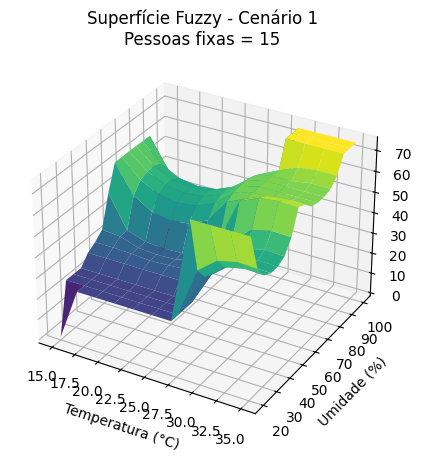

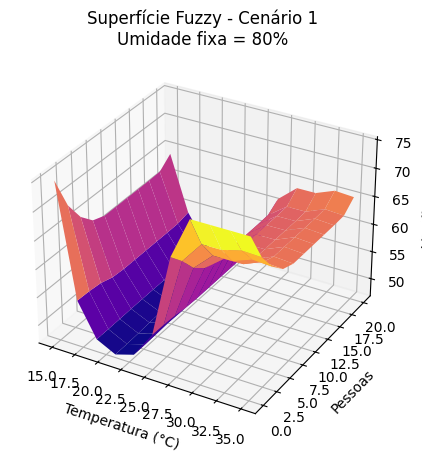

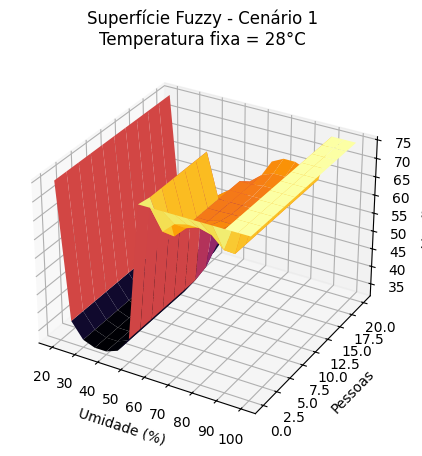

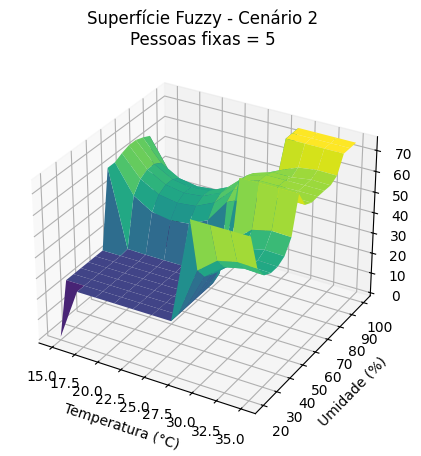

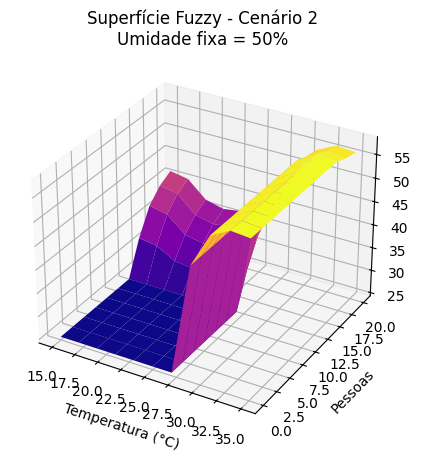

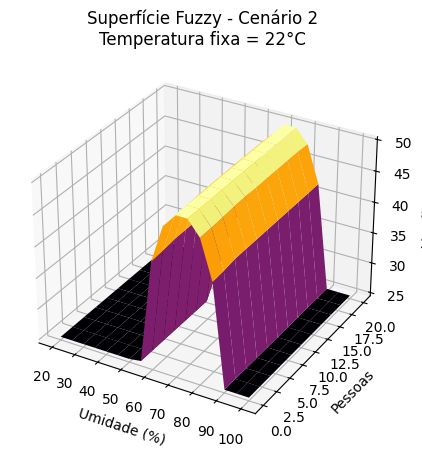

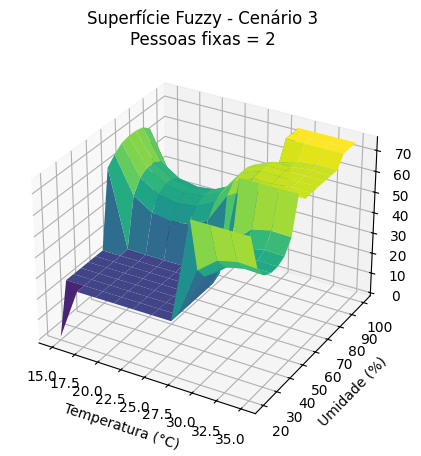

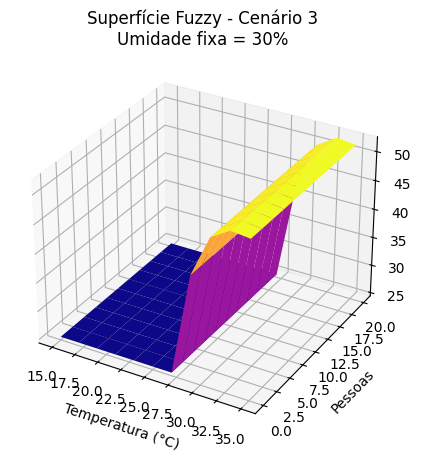

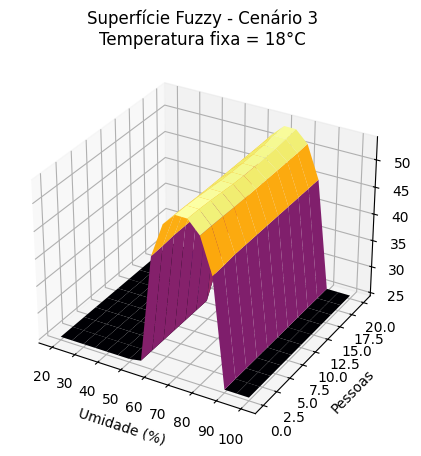

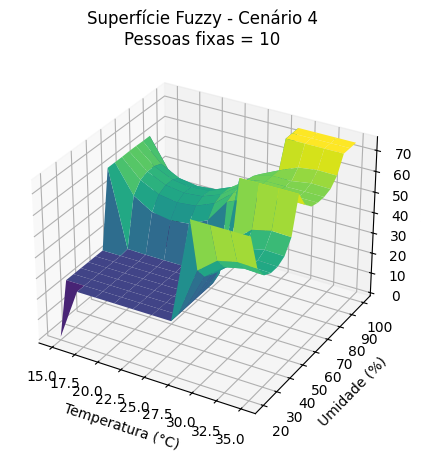

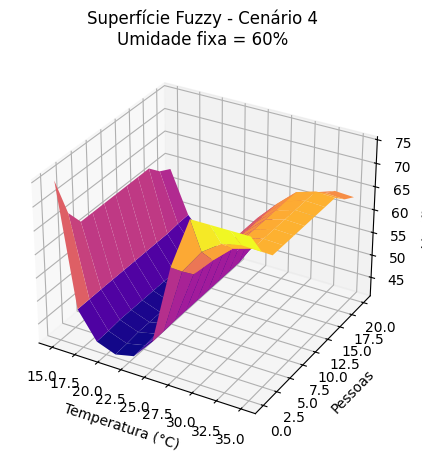

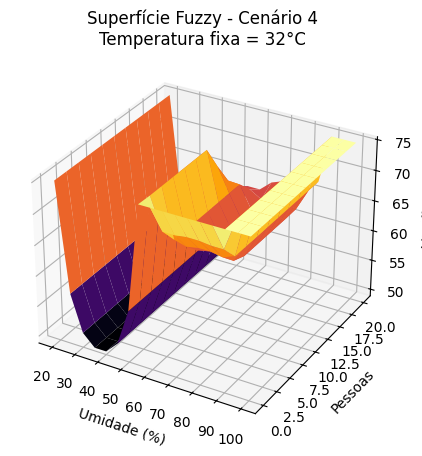

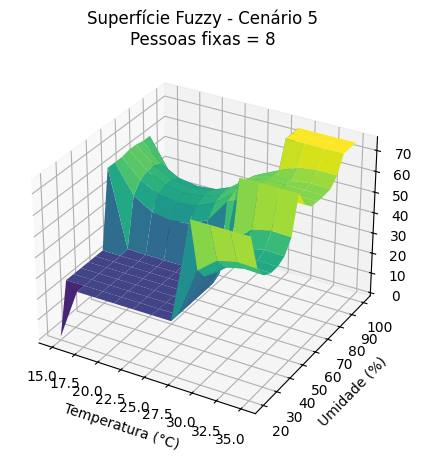

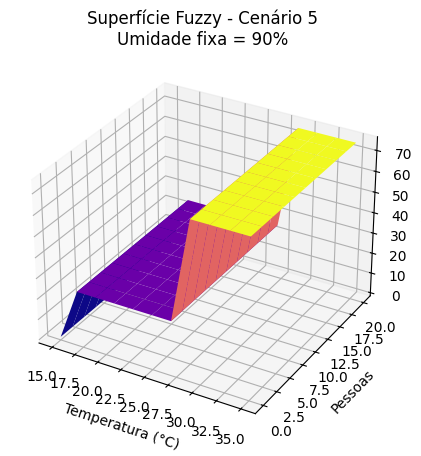

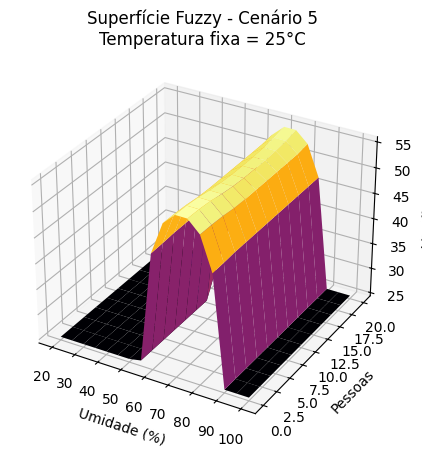

In [130]:
# Superfície fuzzy para cada cenário dos exemplos fornecidos

def superficie_cenario(cenario, idx):
    # Varia duas variáveis e fixa a terceira conforme o cenário
    temp_fix = cenario['temperatura']
    umid_fix = cenario['umidade']
    pess_fix = cenario['pessoas']

    # Superfície 1: fixa pessoas, varia temperatura e umidade
    x = np.arange(15, 36, 2)  # Temperatura
    y = np.arange(20, 101, 5) # Umidade
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X, dtype=float)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            entrada = {'temperatura': X[i, j], 'umidade': Y[i, j], 'pessoas': pess_fix}
            saida_vent, _, _, _, _ = mamdani(entrada)
            Z[i, j] = defuzz_centroide(vent_univ, saida_vent)
    fig = plt.figure(figsize=(7,5))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_xlabel('Temperatura (°C)')
    ax.set_ylabel('Umidade (%)')
    ax.set_zlabel('Ventilação')
    plt.title(f'Superfície Fuzzy - Cenário {idx+1}\nPessoas fixas = {pess_fix}')
    plt.savefig(f"img/superficie_cenario{idx+1}_fixapessoas.png")
    plt.show()

    # Superfície 2: fixa umidade, varia temperatura e pessoas
    x = np.arange(15, 36, 2)  # Temperatura
    y = np.arange(0, 21, 2)   # Pessoas
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X, dtype=float)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            entrada = {'temperatura': X[i, j], 'umidade': umid_fix, 'pessoas': Y[i, j]}
            saida_vent, _, _, _, _ = mamdani(entrada)
            Z[i, j] = defuzz_centroide(vent_univ, saida_vent)
    fig = plt.figure(figsize=(7,5))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='plasma')
    ax.set_xlabel('Temperatura (°C)')
    ax.set_ylabel('Pessoas')
    ax.set_zlabel('Ventilação')
    plt.title(f'Superfície Fuzzy - Cenário {idx+1}\nUmidade fixa = {umid_fix}%')
    plt.savefig(f"img/superficie_cenario{idx+1}_fixaumidade.png")
    plt.show()

    # Superfície 3: fixa temperatura, varia umidade e pessoas
    x = np.arange(20, 101, 5) # Umidade
    y = np.arange(0, 21, 2)   # Pessoas
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X, dtype=float)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            entrada = {'temperatura': temp_fix, 'umidade': X[i, j], 'pessoas': Y[i, j]}
            saida_vent, _, _, _, _ = mamdani(entrada)
            Z[i, j] = defuzz_centroide(vent_univ, saida_vent)
    fig = plt.figure(figsize=(7,5))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='inferno')
    ax.set_xlabel('Umidade (%)')
    ax.set_ylabel('Pessoas')
    ax.set_zlabel('Ventilação')
    plt.title(f'Superfície Fuzzy - Cenário {idx+1}\nTemperatura fixa = {temp_fix}°C')
    plt.savefig(f"img/superficie_cenario{idx+1}_fixatemperatura.png")
    plt.show()

# Gerar superfícies para cada cenário
for idx, c in enumerate(cenarios):
    superficie_cenario(c, idx)

## 8. Processo Detalhado

Demonstração completa do processo fuzzy para cada cenário


--- Cenário 1 ---
Fuzzificação (graus de pertinência):
  Temperatura: {'baixa': 0.0, 'media': 0.912, 'alta': 0.088}
  Umidade: {'baixa': 0.0, 'media': 0.0, 'alta': 0.567}
  Pessoas: {'poucas': 0.798, 'moderado': 0.202, 'muitas': 0.0}

Regras ativadas e firing strength:
  R1: forte (nível=0.567)
  R6: moderada (nível=0.567)
  R9: forte (nível=0.567)

Defuzzificação:
  Centroide: 62.44
  Média do Máximo: 62.45
  Bissetriz: 62.40


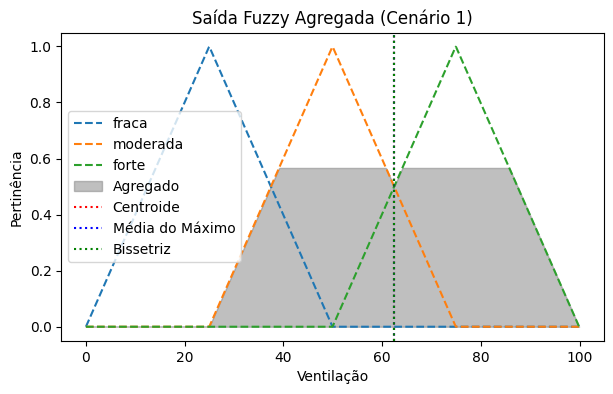


--- Cenário 2 ---
Fuzzificação (graus de pertinência):
  Temperatura: {'baixa': 0.876, 'media': 0.124, 'alta': 0.0}
  Umidade: {'baixa': 0.283, 'media': 0.717, 'alta': 0.0}
  Pessoas: {'poucas': 0.401, 'moderado': 0.0, 'muitas': 0.0}

Regras ativadas e firing strength:
  R3: fraca (nível=0.283)
  R7: fraca (nível=0.876)

Defuzzificação:
  Centroide: 24.98
  Média do Máximo: 24.95
  Bissetriz: 25.00


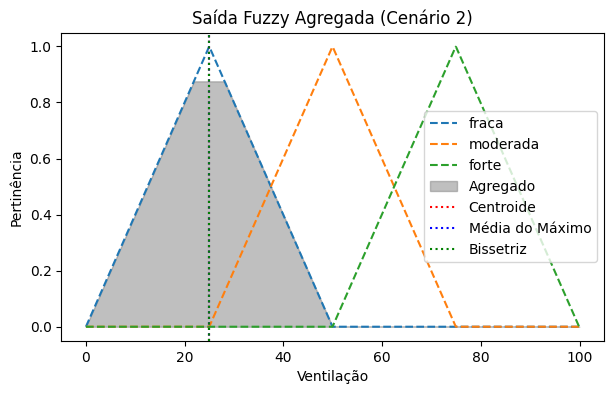


--- Cenário 3 ---
Fuzzificação (graus de pertinência):
  Temperatura: {'baixa': 0.482, 'media': 0.0, 'alta': 0.0}
  Umidade: {'baixa': 0.572, 'media': 0.0, 'alta': 0.0}
  Pessoas: {'poucas': 0.16, 'moderado': 0.0, 'muitas': 0.0}

Regras ativadas e firing strength:
  R3: fraca (nível=0.160)
  R7: fraca (nível=0.572)

Defuzzificação:
  Centroide: 24.98
  Média do Máximo: 24.95
  Bissetriz: 25.00


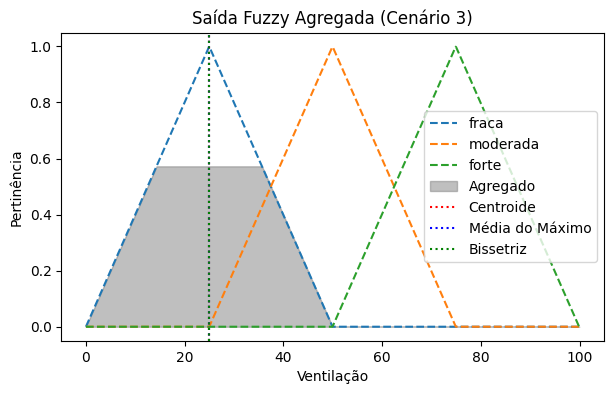


--- Cenário 4 ---
Fuzzificação (graus de pertinência):
  Temperatura: {'baixa': 0.0, 'media': 0.269, 'alta': 0.731}
  Umidade: {'baixa': 0.0, 'media': 0.711, 'alta': 0.289}
  Pessoas: {'poucas': 0.802, 'moderado': 0.0, 'muitas': 0.0}

Regras ativadas e firing strength:
  R1: forte (nível=0.731)
  R6: moderada (nível=0.289)
  R9: forte (nível=0.269)

Defuzzificação:
  Centroide: 66.88
  Média do Máximo: 74.95
  Bissetriz: 70.00


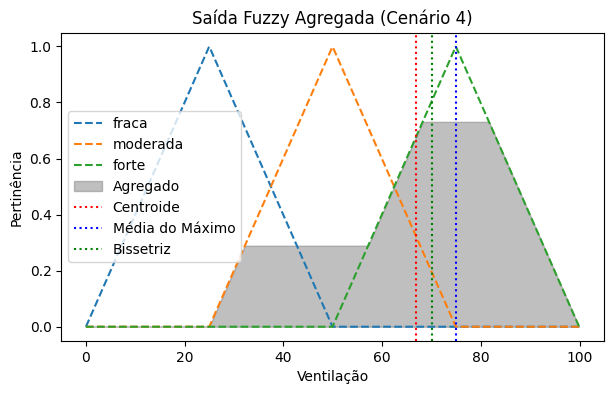


--- Cenário 5 ---
Fuzzificação (graus de pertinência):
  Temperatura: {'baixa': 0.394, 'media': 0.606, 'alta': 0.0}
  Umidade: {'baixa': 0.0, 'media': 0.0, 'alta': 0.0}
  Pessoas: {'poucas': 0.641, 'moderado': 0.0, 'muitas': 0.0}

Regras ativadas e firing strength:
  R7: fraca (nível=0.394)

Defuzzificação:
  Centroide: 24.98
  Média do Máximo: 25.00
  Bissetriz: 25.00


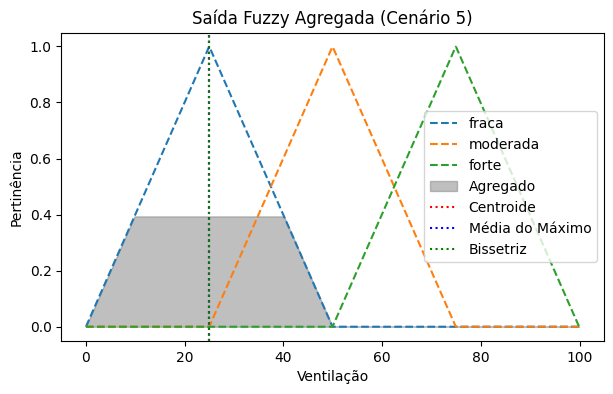

In [131]:
def analisar_cenario(entrada, idx=None):
    """
    Executa a análise fuzzy completa para um cenário de entrada.
    Parâmetros:
        entrada: dicionário com as chaves 'temperatura', 'umidade', 'pessoas'
        idx: número do cenário (opcional, para exibição)
    """
    saida_vent, regras_ativadas, mu_temp, mu_umid, mu_pess = mamdani(entrada)
    if idx is not None:
        print(f"\n--- Cenário {idx+1} ---")
    print("Fuzzificação (graus de pertinência):")
    print("  Temperatura:", {k: float(f"{v:.3f}") for k, v in mu_temp.items()})
    print("  Umidade:", {k: float(f"{v:.3f}") for k, v in mu_umid.items()})
    print("  Pessoas:", {k: float(f"{v:.3f}") for k, v in mu_pess.items()})
    print("\nRegras ativadas e firing strength:")
    for reg, nome, firing in regras_ativadas:
        print(f"  {reg}: {nome} (nível={firing:.3f})")
    centroide = defuzz_centroide(vent_univ, saida_vent)
    media_max = defuzz_media_maximo(vent_univ, saida_vent)
    bissetriz = defuzz_bissetriz(vent_univ, saida_vent)
    print(f"\nDefuzzificação:")
    print(f"  Centroide: {centroide:.2f}")
    print(f"  Média do Máximo: {media_max:.2f}")
    print(f"  Bissetriz: {bissetriz:.2f}")
    # Visualização da saída fuzzy agregada
    plt.figure(figsize=(7,4))
    plt.plot(vent_univ, vent_fraca(vent_univ), '--', label='fraca')
    plt.plot(vent_univ, vent_moderada(vent_univ), '--', label='moderada')
    plt.plot(vent_univ, vent_forte(vent_univ), '--', label='forte')
    plt.fill_between(vent_univ, 0, saida_vent, color='gray', alpha=0.5, label='Agregado')
    plt.axvline(centroide, color='red', linestyle=':', label='Centroide')
    plt.axvline(media_max, color='blue', linestyle=':', label='Média do Máximo')
    plt.axvline(bissetriz, color='green', linestyle=':', label='Bissetriz')
    plt.title(f'Saída Fuzzy Agregada (Cenário {idx+1})' if idx is not None else 'Saída Fuzzy Agregada')
    plt.xlabel('Ventilação')
    plt.ylabel('Pertinência')
    plt.legend()
    # Salva o gráfico para cada cenário
    if idx is not None:
        if not os.path.exists("img"):
            os.makedirs("img")
        plt.savefig(f"img/defuzz_cenario{idx+1}.png")
    plt.show()

# Exemplo de uso para todos os cenários:
for idx, entrada in enumerate(cenarios):
    analisar_cenario(entrada, idx)

## 9. Interpretação Qualitativa

A intensidade de ventilação sugerida para o cenário 1 é:

In [132]:
import pandas as pd

resultados = []
for idx, entrada in enumerate(cenarios):
    saida_vent, _, _, _, _ = mamdani(entrada)
    centroide = defuzz_centroide(vent_univ, saida_vent)
    if centroide < 4:
        nivel = "fraca"
    elif centroide < 7:
        nivel = "moderada"
    else:
        nivel = "forte"
    resultados.append({
        "Cenário": idx+1,
        "Temperatura": entrada['temperatura'],
        "Umidade": entrada['umidade'],
        "Pessoas": entrada['pessoas'],
        "Centroide": f"{centroide:.2f}",
        "Intensidade": nivel.upper()
    })

df = pd.DataFrame(resultados)
print(df.to_string(index=False))

# Exibir em LaTeX
print("\nTabela em LaTeX:\n")
print(df.to_latex(index=False, caption="Resultados dos Cenários - Intensidade de Ventilação Sugerida", label="tab:ventilacao"))

 Cenário  Temperatura  Umidade  Pessoas Centroide Intensidade
       1           28       80       15     62.44       FORTE
       2           22       50        5     24.98       FORTE
       3           18       30        2     24.98       FORTE
       4           32       60       10     66.88       FORTE
       5           25       90        8     24.98       FORTE

Tabela em LaTeX:

\begin{table}
\caption{Resultados dos Cenários - Intensidade de Ventilação Sugerida}
\label{tab:ventilacao}
\begin{tabular}{rrrrll}
\toprule
Cenário & Temperatura & Umidade & Pessoas & Centroide & Intensidade \\
\midrule
1 & 28 & 80 & 15 & 62.44 & FORTE \\
2 & 22 & 50 & 5 & 24.98 & FORTE \\
3 & 18 & 30 & 2 & 24.98 & FORTE \\
4 & 32 & 60 & 10 & 66.88 & FORTE \\
5 & 25 & 90 & 8 & 24.98 & FORTE \\
\bottomrule
\end{tabular}
\end{table}



## 10. Discussão

- O sistema fuzzy Mamdani permite decisões qualitativas interpretáveis.
- A escolha dos operadores e técnicas de defuzzificação pode alterar levemente o valor final, mas a tendência qualitativa se mantém.
- O método centroide é o mais estável e sensível a todas as ativações.
- O sistema pode ser facilmente ajustado para outros ambientes ou critérios de conforto.

Vamos analisar o impacto prático dos operadores fuzzy tradicionais e alternativos nos exemplos abaixo:

Exemplo 1:
Entradas com pertinências: 0.7 e 0.4

AND (mínimo):
min(0.7, 0.4) = 0.4
O resultado é igual ao menor valor. Se uma condição for baixa, o resultado é limitado por ela.

AND (produto):
0.7 * 0.4 = 0.28
O resultado é ainda menor. Se uma condição for baixa, o resultado cai mais rápido. Isso deixa o sistema mais rigoroso, pois qualquer entrada baixa reduz muito a ativação da regra.

OR (máximo):
max(0.7, 0.4) = 0.7
O resultado é igual ao maior valor. Basta uma condição ser alta para a regra ser bem ativada.

OR (soma limitada):
min(0.7 + 0.4, 1) = 1.0
O resultado pode ser maior que qualquer entrada individual, mas nunca passa de 1. Se várias condições forem parcialmente verdadeiras, a ativação da regra pode ser maior do que usando apenas o máximo.

O que isso acarreta no sistema fuzzy?
AND (mínimo):
O sistema é conservador: exige que todas as condições estejam bem satisfeitas para ativar a regra.

AND (produto):
O sistema é ainda mais restritivo: qualquer entrada baixa reduz muito a ativação, tornando o sistema mais sensível a entradas baixas.

OR (máximo):
O sistema é permissivo: basta uma condição ser alta para ativar a regra.

OR (soma limitada):
O sistema pode ativar mais fortemente quando várias condições são parcialmente verdadeiras, tornando-o mais flexível e sensível a múltiplas condições moderadas.

Resumo:
A escolha do operador afeta diretamente a sensibilidade e o comportamento do sistema fuzzy.

Produto para AND deixa o sistema mais rigoroso.
Soma limitada para OR deixa o sistema mais flexível quando há várias condições parcialmente verdadeiras.
Essas escolhas devem ser feitas conforme o perfil de resposta desejado para o seu problema.

In [ ]:
!jupyter nbconvert --to script d:\GitHub\DoutoradoCefet\InteligenciaComputacional\Trabalho02\Mandani\mamdani2.ipynb